# 06 - Modele Arbre de decision

## 1. Objectif et protocole

Documenter le compromis performance/complexite d'un arbre unique et ses limites de generalisation.

Protocole publie dans ce notebook:
- `simple CV` stratifiee pour comparer les variantes non tunees.
- `GridSearchCV` pour cartographier l'espace hyperparametrique de maniere exploratoire.
- `nested CV` pour la performance finale confirmatoire.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

from src.evaluation import (
    calculer_brier_score_multiclasse,
    calculer_statistiques_confiance,
    calculer_top_k_accuracies,
    matrice_confusion_normalisee,
    classes_difficiles,
    top_confusions,
    verifier_overfit_petit_echantillon,
)
from src.notebook_support import (
    calculer_importance_permutation_exploratoire,
    calculer_metriques_classes_depuis_predictions,
    charger_ou_generer_predictions_variante,
    construire_tableau_gaps,
    construire_resume_confusions_variantes,
    construire_tableau_plis_externes,
    construire_tableau_variantes,
    creer_notebook_context,
    evaluer_variantes_untuned,
    executer_tuning_confirmatoire,
    executer_verifications_validite,
)
from src.plots import (
    tracer_comparaison_variantes,
    tracer_heatmap_tuning,
    tracer_histogramme_confiance,
    tracer_hyperparametre_vs_performance,
    tracer_matrice_confusion,
    tracer_metrique_par_classe,
    tracer_reliability_diagram,
    tracer_top_confusions,
)
from src.evaluation.diagnostics_specifiques import validation_curve_max_depth
from src.plots.specifiques.arbre_decision import tracer_validation_curve_max_depth

In [2]:
MODEL_NAME = "arbre_decision"
ctx = creer_notebook_context(MODEL_NAME)
spec = ctx.spec
definition = ctx.definition
X, y, label_encoder = ctx.X, ctx.y, ctx.label_encoder

protocole = pd.DataFrame(
    [
        ("Modele", definition["nom_affiche"]),
        ("Famille", definition["famille"]),
        ("Metrique principale", "macro-F1"),
        ("Exploration", "simple CV + grid search"),
        ("Confirmation", "nested CV"),
    ],
    columns=["axe", "choix"],
)
display(protocole)


,axe,choix
0,Modele,Arbre de decision
1,Famille,arbre
2,Metrique principale,macro-F1
3,Exploration,simple CV + grid search
4,Confirmation,nested CV


## 2. Signal attendu et design experimental

**Design experimental**
- L'arbre de decision est analyse comme modele interpretable mais instable.
- La variante de profondeur restreinte reste un controle de complexite simple.
- Le tuning etudie explicitement la profondeur, la taille de feuille et l'elagage cost-complexity.

**Signal attendu**
- L'arbre unique devrait rester derriere la foret en performance et en stabilite inter-plis.
- Sa valeur scientifique principale est interpretative: profondeur, elagage et top erreurs doivent raconter la limite de generalisation.

**Refutation pratique**
- Si ces motifs n'apparaissent pas, ou s'inversent dans la `nested CV`, l'hypothese du modele n'est pas consideree comme confirmee.


In [3]:
design_table = pd.DataFrame(
    {
        "variante": [variant.name for variant in spec.untuned_variants],
        "type": [variant.kind for variant in spec.untuned_variants],
        "parametres_forces": [variant.params or {} for variant in spec.untuned_variants],
    }
)
display(design_table)


,variante,type,parametres_forces
0,default,simple,{}
1,restricted_depth,simple,{'max_depth': 10}


## 3. Resultats exploratoires non tunes

Cette section sert a mesurer les variantes sans selection d'hyperparametres finale.
Les gaps train/validation restent uniquement descriptifs a ce stade.


,variante,selection_protocol,evaluation_stage,val_accuracy_mean,val_accuracy_std,val_f1_macro_mean,val_f1_macro_std,train_accuracy_mean,train_f1_macro_mean,generalization_gap_accuracy,generalization_gap_f1_macro,elapsed_seconds,timing_policy
0,default,simple_cv,baseline,0.6586,0.0240,0.6368,0.0322,1.0000,1.0000,0.3414,0.3632,1.1462,cv_n_jobs=1
1,restricted_depth,simple_cv,improved_untuned,0.2152,0.0301,0.1790,0.0268,0.2881,0.2561,0.0730,0.0772,0.6537,cv_n_jobs=1


,variante,generalization_gap_accuracy,generalization_gap_f1_macro
0,default,0.3414,0.3632
1,restricted_depth,0.0730,0.0772


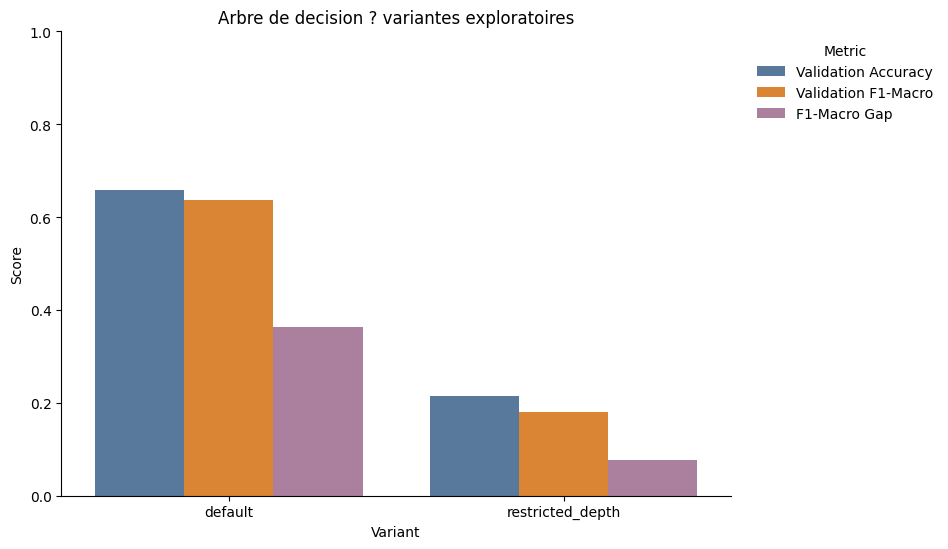

In [4]:
untuned_results = evaluer_variantes_untuned(ctx)
untuned_table = construire_tableau_variantes(untuned_results, None)
gap_table = construire_tableau_gaps(untuned_results)

display(untuned_table.round(4))
display(gap_table.round(4))

tracer_comparaison_variantes(
    untuned_table[[
        "variante",
        "val_accuracy_mean",
        "val_f1_macro_mean",
        "generalization_gap_f1_macro",
    ]],
    ["val_accuracy_mean", "val_f1_macro_mean", "generalization_gap_f1_macro"],
    titre=f"{definition['nom_affiche']} ? variantes exploratoires",
)
plt.show()


## 4. Resultat confirmatoire tuned

Les cartes du `GridSearchCV` restent exploratoires. La seule performance finale a commenter
comme resultat confirmatoire est la ligne `tuned` obtenue en `nested CV`.


In [5]:
tuning = executer_tuning_confirmatoire(ctx)
summary_table = construire_tableau_variantes(untuned_results, tuning["metrics"])
fold_table = construire_tableau_plis_externes(tuning["nested"])
grid_results = tuning["grid_results"].copy()
shortlist = grid_results.sort_values("rank_test_f1_macro").head(10)

display(summary_table.round(4))
display(fold_table.round(4))

colonnes_shortlist = [
    colonne
    for colonne in [
        "rank_test_f1_macro",
        "mean_test_f1_macro",
        "std_test_f1_macro",
        "mean_fit_time",
    ] + [col for col in shortlist.columns if col.startswith("param_")]
    if colonne in shortlist.columns
]
display(shortlist[colonnes_shortlist].round(4))

if spec.tuning_heatmap_axes is not None:
    axe_x, axe_y = spec.tuning_heatmap_axes
    colonne_facette = spec.tuning_facet_column
    if colonne_facette and colonne_facette in grid_results.columns:
        for valeur_facette, sous_tableau in grid_results.groupby(colonne_facette):
            if sous_tableau[[axe_x, axe_y]].drop_duplicates().shape[0] != len(sous_tableau):
                continue
            tracer_heatmap_tuning(
                sous_tableau,
                x=axe_x,
                y=axe_y,
                valeur="mean_test_f1_macro",
                titre=f"{definition['nom_affiche']} ? tuning exploratoire ({colonne_facette}={valeur_facette})",
            )
            plt.show()
    elif axe_x in grid_results.columns and axe_y in grid_results.columns:
        if grid_results[[axe_x, axe_y]].drop_duplicates().shape[0] == len(grid_results):
            tracer_heatmap_tuning(
                grid_results,
                x=axe_x,
                y=axe_y,
                valeur="mean_test_f1_macro",
                titre=f"{definition['nom_affiche']} ? tuning exploratoire",
            )
            plt.show()
        else:
            tracer_hyperparametre_vs_performance(
                grid_results,
                x=axe_x,
                y="mean_test_f1_macro",
                hue=axe_y,
                titre=f"{definition['nom_affiche']} ? lecture exploratoire du tuning",
            )
            plt.show()


,variante,selection_protocol,evaluation_stage,val_accuracy_mean,val_accuracy_std,val_f1_macro_mean,val_f1_macro_std,train_accuracy_mean,train_f1_macro_mean,generalization_gap_accuracy,generalization_gap_f1_macro,elapsed_seconds,timing_policy
0,default,simple_cv,baseline,0.6586,0.0240,0.6368,0.0322,1.0000,1.0000,0.3414,0.3632,1.1462,cv_n_jobs=1
1,tuned,nested_cv,tuned,0.5384,0.0540,0.5072,0.0539,NaN,NaN,NaN,NaN,13.8971,cv_n_jobs=1
2,restricted_depth,simple_cv,improved_untuned,0.2152,0.0301,0.1790,0.0268,0.2881,0.2561,0.0730,0.0772,0.6537,cv_n_jobs=1


,fold,train_accuracy,train_f1_macro,val_accuracy,val_f1_macro,fit_time,score_time,best_score_inner
0,1,0.8485,0.8435,0.5707,0.5372,2.7754,0.001,0.3954
1,2,0.6477,0.6263,0.4444,0.4157,2.7766,0.001,0.4064
2,3,0.7891,0.7746,0.5707,0.5361,2.8140,0.001,0.3673
3,4,0.7689,0.7470,0.5404,0.5014,2.7871,0.002,0.3596
4,5,0.8182,0.8112,0.5657,0.5455,2.7155,0.001,0.4411


,rank_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,mean_fit_time,param_ccp_alpha,param_criterion,param_max_depth,param_min_samples_leaf
2,1,0.4760,0.0189,0.1592,0.000,gini,20,1
3,2,0.4757,0.0143,0.1663,0.000,gini,20,4
7,3,0.4722,0.0134,0.1521,0.005,gini,20,4
6,4,0.4698,0.0088,0.1779,0.005,gini,20,1
0,5,0.1879,0.0144,0.0950,0.000,gini,10,1
1,6,0.1879,0.0142,0.0925,0.000,gini,10,4
5,6,0.1879,0.0142,0.0945,0.005,gini,10,4
4,8,0.1846,0.0128,0.0921,0.005,gini,10,1


## 5. Verifications de validite scientifique

Cette section impose le meme contrat minimal dans tous les notebooks:
baseline dummy, test de bruit aleatoire et rappel protocolaire.


In [6]:
validite = executer_verifications_validite(ctx)
display(Markdown(f"**Note protocolaire.** {validite['note']}"))
display(validite["dummy"].round(4))
display(validite["random_noise"].round(4))

if MODEL_NAME == "mlp":
    mini_overfit = pd.DataFrame([verifier_overfit_petit_echantillon()])
    display(Markdown("**Sanity check additionnel MLP.** Ce test verifie qu'un reseau dense peut sur-apprendre un micro-echantillon synthetique."))
    display(mini_overfit.round(4))


**Note protocolaire.** Les variantes non tunees et les figures refittees sur tout le dataset restent exploratoires. Les seuls chiffres confirmatoires a commenter comme performance finale sont ceux de la variante tuned en nested CV.

,val_accuracy_mean,val_accuracy_std,val_f1_macro_mean,val_f1_macro_std,train_accuracy_mean,train_f1_macro_mean,fit_time_mean,score_time_mean,elapsed_seconds,n_splits,modele,variante,reference
0,0.0101,0.0,0.0002,0.0,0.0101,0.0002,0.0008,0.0015,0.0219,5,dummy,most_frequent,DummyClassifier


,val_accuracy_mean,val_f1_macro_mean,chance_level,near_chance,reference
0,0.0081,0.0066,0.0101,True,Bruit aleatoire


## 6. Diagnostics du modele

Les tableaux et graphiques issus des predictions `OOF` de la `nested CV` sont confirmatoires.
Les diagnostics issus d'un refit global ou du `grid search` complet sont explicitement exploratoires.


,classe,precision,recall,f1,support,fpr,fnr,specificite
0,Acer_Opalus,0.0000,0.0,0.0000,10,0.0000,1.0,1.0000
1,Quercus_Castaneifolia,0.0000,0.0,0.0000,10,0.0010,1.0,0.9990
2,Pterocarya_Stenoptera,0.0000,0.0,0.0000,10,0.0010,1.0,0.9990
3,Viburnum_Tinus,0.0000,0.0,0.0000,10,0.0010,1.0,0.9990
4,Quercus_Suber,0.0000,0.0,0.0000,10,0.0010,1.0,0.9990
5,Quercus_x_Hispanica,0.0000,0.0,0.0000,10,0.0000,1.0,1.0000
6,Quercus_Semecarpifolia,0.0000,0.0,0.0000,10,0.0010,1.0,0.9990
7,Quercus_Kewensis,0.0000,0.0,0.0000,10,0.0020,1.0,0.9980
8,Quercus_Infectoria_sub,0.3333,0.1,0.1538,10,0.0020,0.9,0.9980
9,Quercus_Trojana,0.5000,0.1,0.1667,10,0.0010,0.9,0.9990


,classe_vraie,classe_predite,nombre_erreurs
0,Quercus_Suber,Quercus_Alnifolia,8
1,Quercus_x_Hispanica,Quercus_Alnifolia,7
2,Quercus_Castaneifolia,Quercus_Alnifolia,6
3,Quercus_Semecarpifolia,Quercus_Alnifolia,6
4,Quercus_Crassifolia,Quercus_Alnifolia,5
5,Quercus_Infectoria_sub,Quercus_Alnifolia,5
6,Quercus_Phillyraeoides,Quercus_Alnifolia,5
7,Acer_Opalus,Quercus_Alnifolia,4
8,Lithocarpus_Cleistocarpus,Ilex_Cornuta,4
9,Phildelphus,Liriodendron_Tulipifera,4


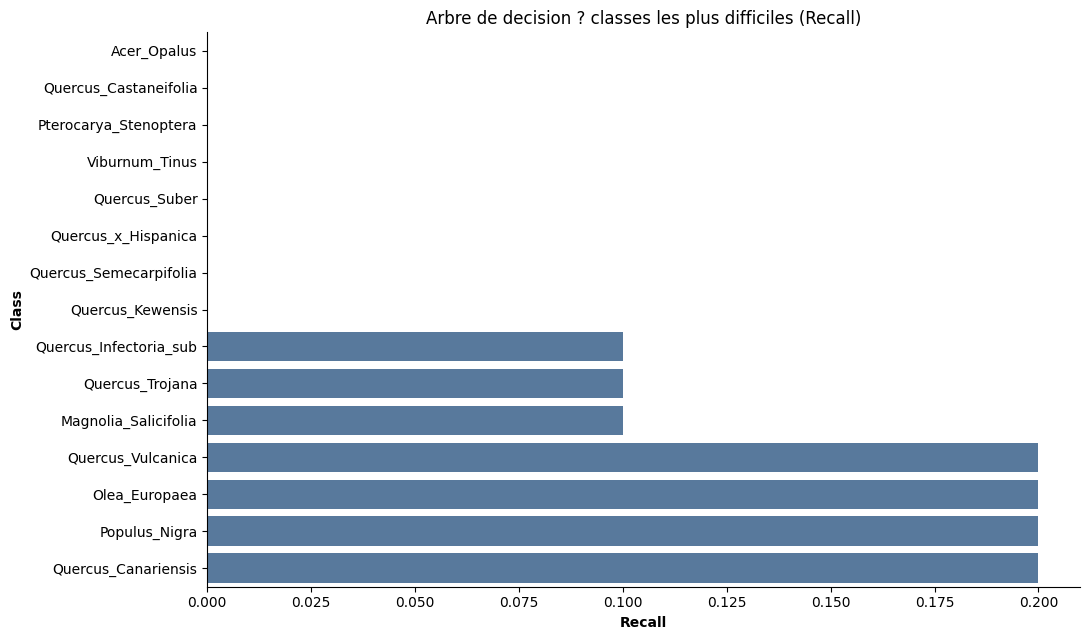

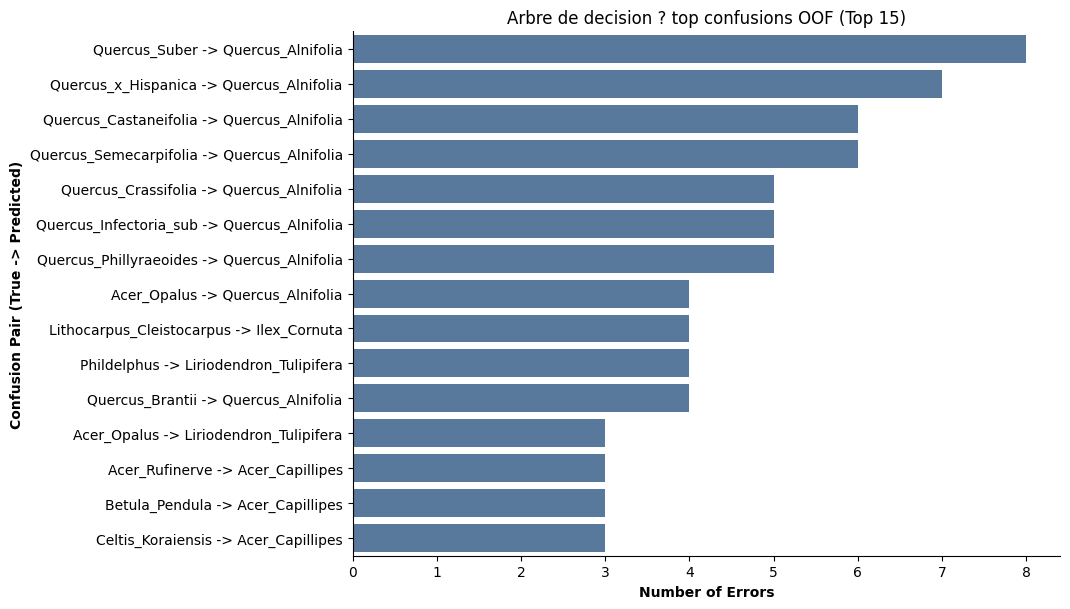

_Aucun diagnostic probabiliste n'est publie pour ce modele dans cette passe._

In [7]:
predictions_tuned = tuning["nested"]["oof_predictions"]
classes_table = calculer_metriques_classes_depuis_predictions(predictions_tuned, label_encoder)
difficult_classes = classes_difficiles(
    predictions_tuned["y_true"].to_numpy(),
    predictions_tuned["y_pred"].to_numpy(),
    label_encoder=label_encoder,
    top_n=15,
    metrique="recall",
)
confusions_table = top_confusions(
    predictions_tuned["y_true"].to_numpy(),
    predictions_tuned["y_pred"].to_numpy(),
    label_encoder=label_encoder,
    top_n=15,
)

display(difficult_classes.round(4))
display(confusions_table.round(4))

tracer_metrique_par_classe(
    classes_table,
    metrique="recall",
    top_n=15,
    ordre="asc",
    titre=f"{definition['nom_affiche']} ? classes les plus difficiles",
)
plt.show()

if not confusions_table.empty:
    tracer_top_confusions(
        confusions_table,
        top_n=min(15, len(confusions_table)),
        titre=f"{definition['nom_affiche']} ? top confusions OOF",
    )
    plt.show()

probabilites_tuned = tuning["nested"].get("oof_probabilities")
if spec.supports_probabilities and probabilites_tuned is not None:
    topk = calculer_top_k_accuracies(probabilites_tuned)
    confiance = calculer_statistiques_confiance(probabilites_tuned)
    brier = calculer_brier_score_multiclasse(probabilites_tuned)
    tableau_probabilites = pd.DataFrame(
        [
            {
                "top_1_accuracy": topk["top_1_accuracy"],
                "top_5_accuracy": topk["top_5_accuracy"],
                "confiance_moyenne": confiance["confiance_moyenne"],
                "confiance_erreurs": confiance["confiance_erreurs"],
                "brier_multiclasse": brier,
            }
        ]
    )
    display(tableau_probabilites.round(4))
    tracer_histogramme_confiance(
        probabilites_tuned,
        titre=f"{definition['nom_affiche']} ? histogramme de confiance OOF",
    )
    plt.show()
    tracer_reliability_diagram(
        probabilites_tuned,
        titre=f"{definition['nom_affiche']} ? reliability diagram OOF",
    )
    plt.show()
else:
    display(Markdown("_Aucun diagnostic probabiliste n'est publie pour ce modele dans cette passe._"))


### Matrices de confusion par variante

Les matrices ci-dessous enrichissent la lecture des erreurs pour chaque variante du modele.
- pour `tuned`, les predictions proviennent des artefacts `OOF` de la `nested CV` ;
- pour les variantes non tunees, les predictions sont reconstruites en `simple CV` avec le protocole partage.

Cette comparaison reste descriptive : elle permet d'observer la structure des erreurs sans transformer
les variantes exploratoires en resultats confirmatoires.


,variante,evaluation_stage,val_f1_macro_mean,val_accuracy_mean,generalization_gap_f1_macro,confusion_dominante,nombre_erreurs_dominantes
0,default,baseline,0.6368,0.6586,0.3632,Populus_Adenopoda -> Quercus_Ilex,4
1,restricted_depth,improved_untuned,0.1790,0.2152,0.0772,Acer_Rufinerve -> Acer_Capillipes,8
2,tuned,tuned,0.5072,0.5384,NaN,Quercus_Suber -> Quercus_Alnifolia,8


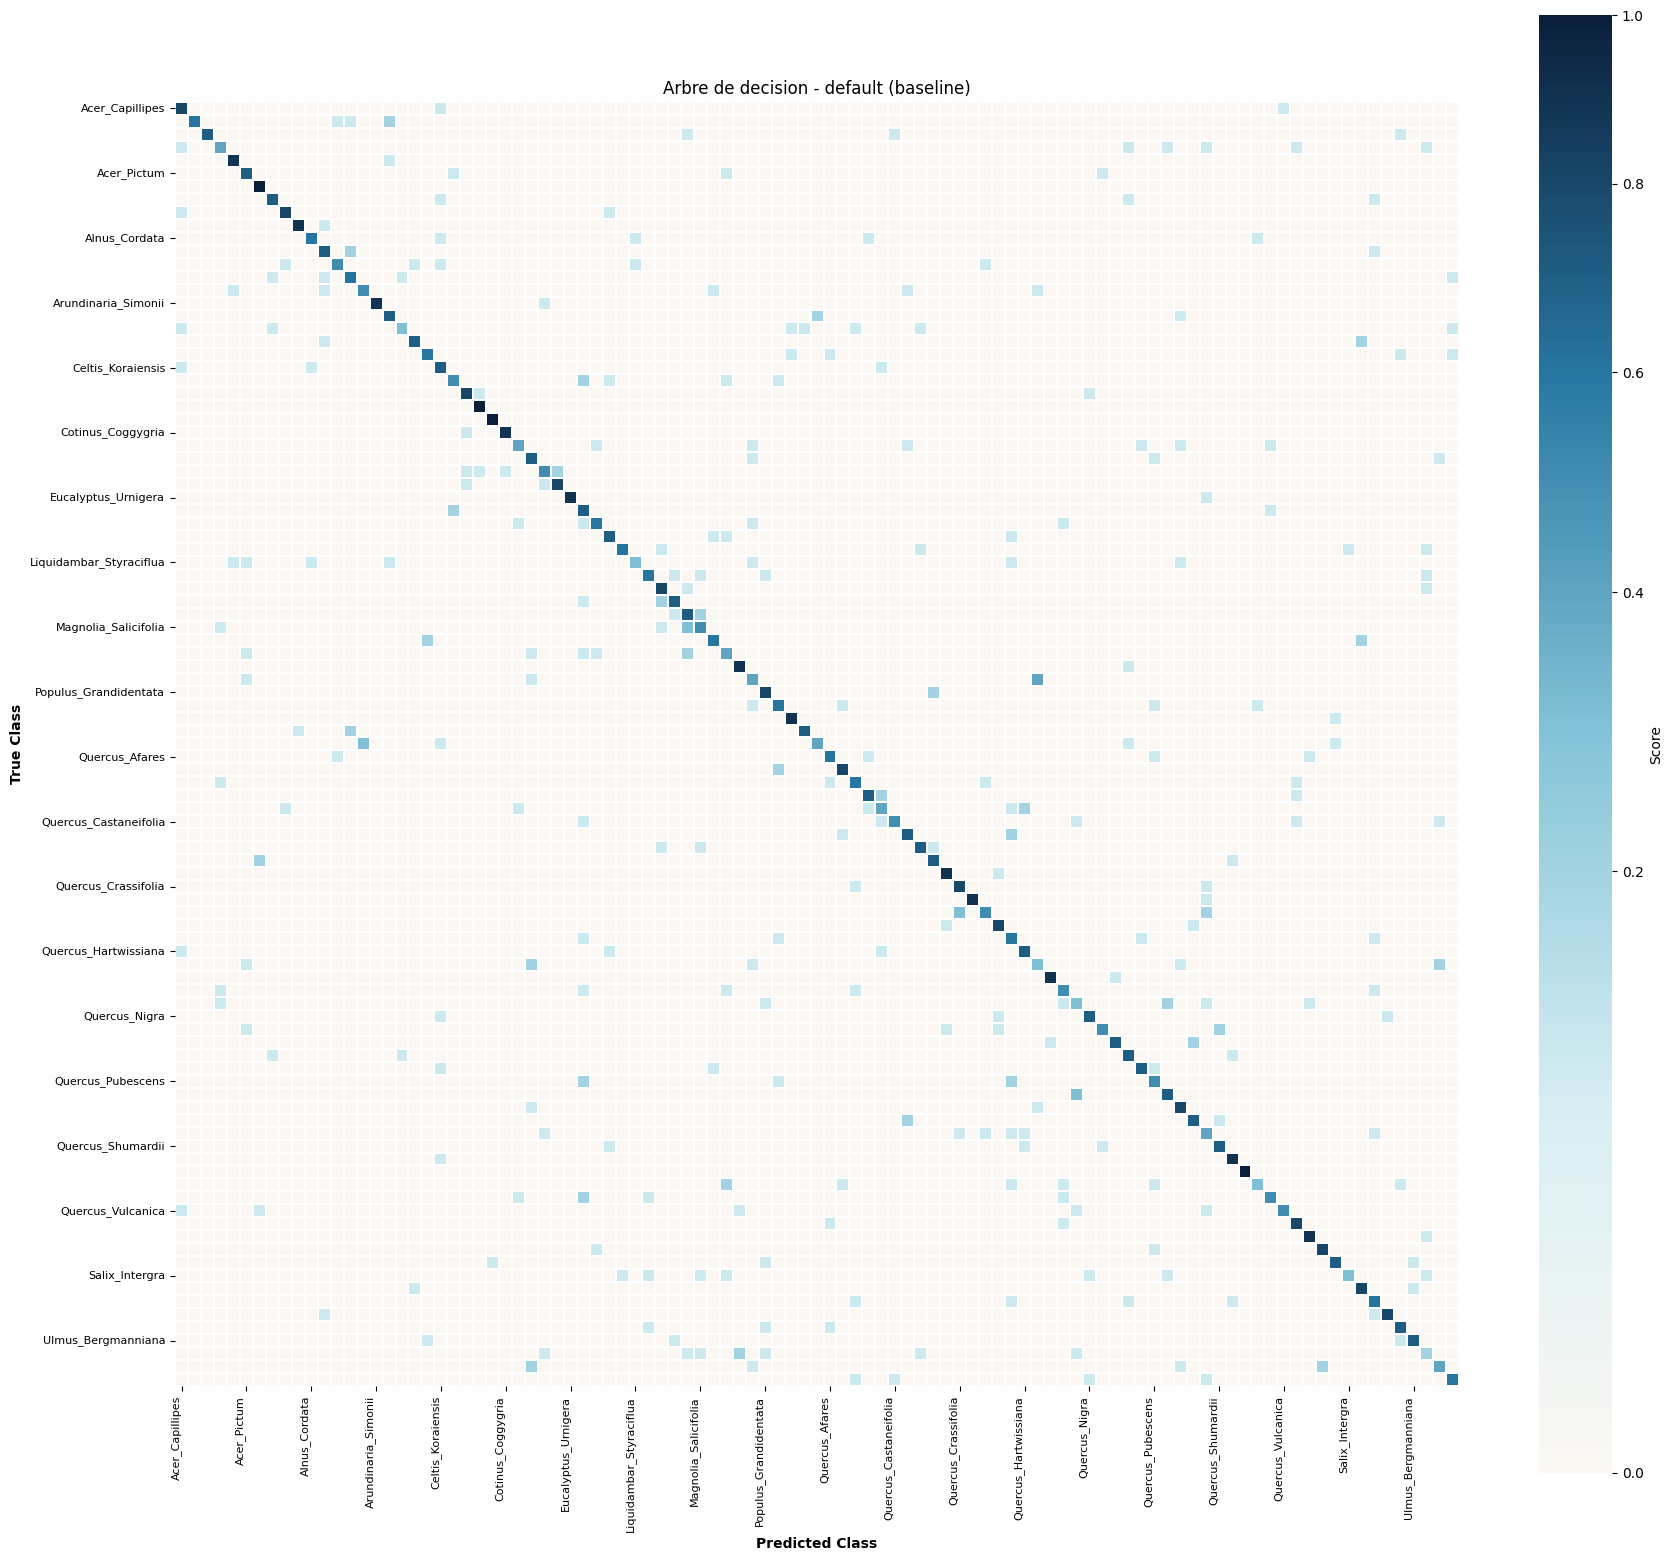

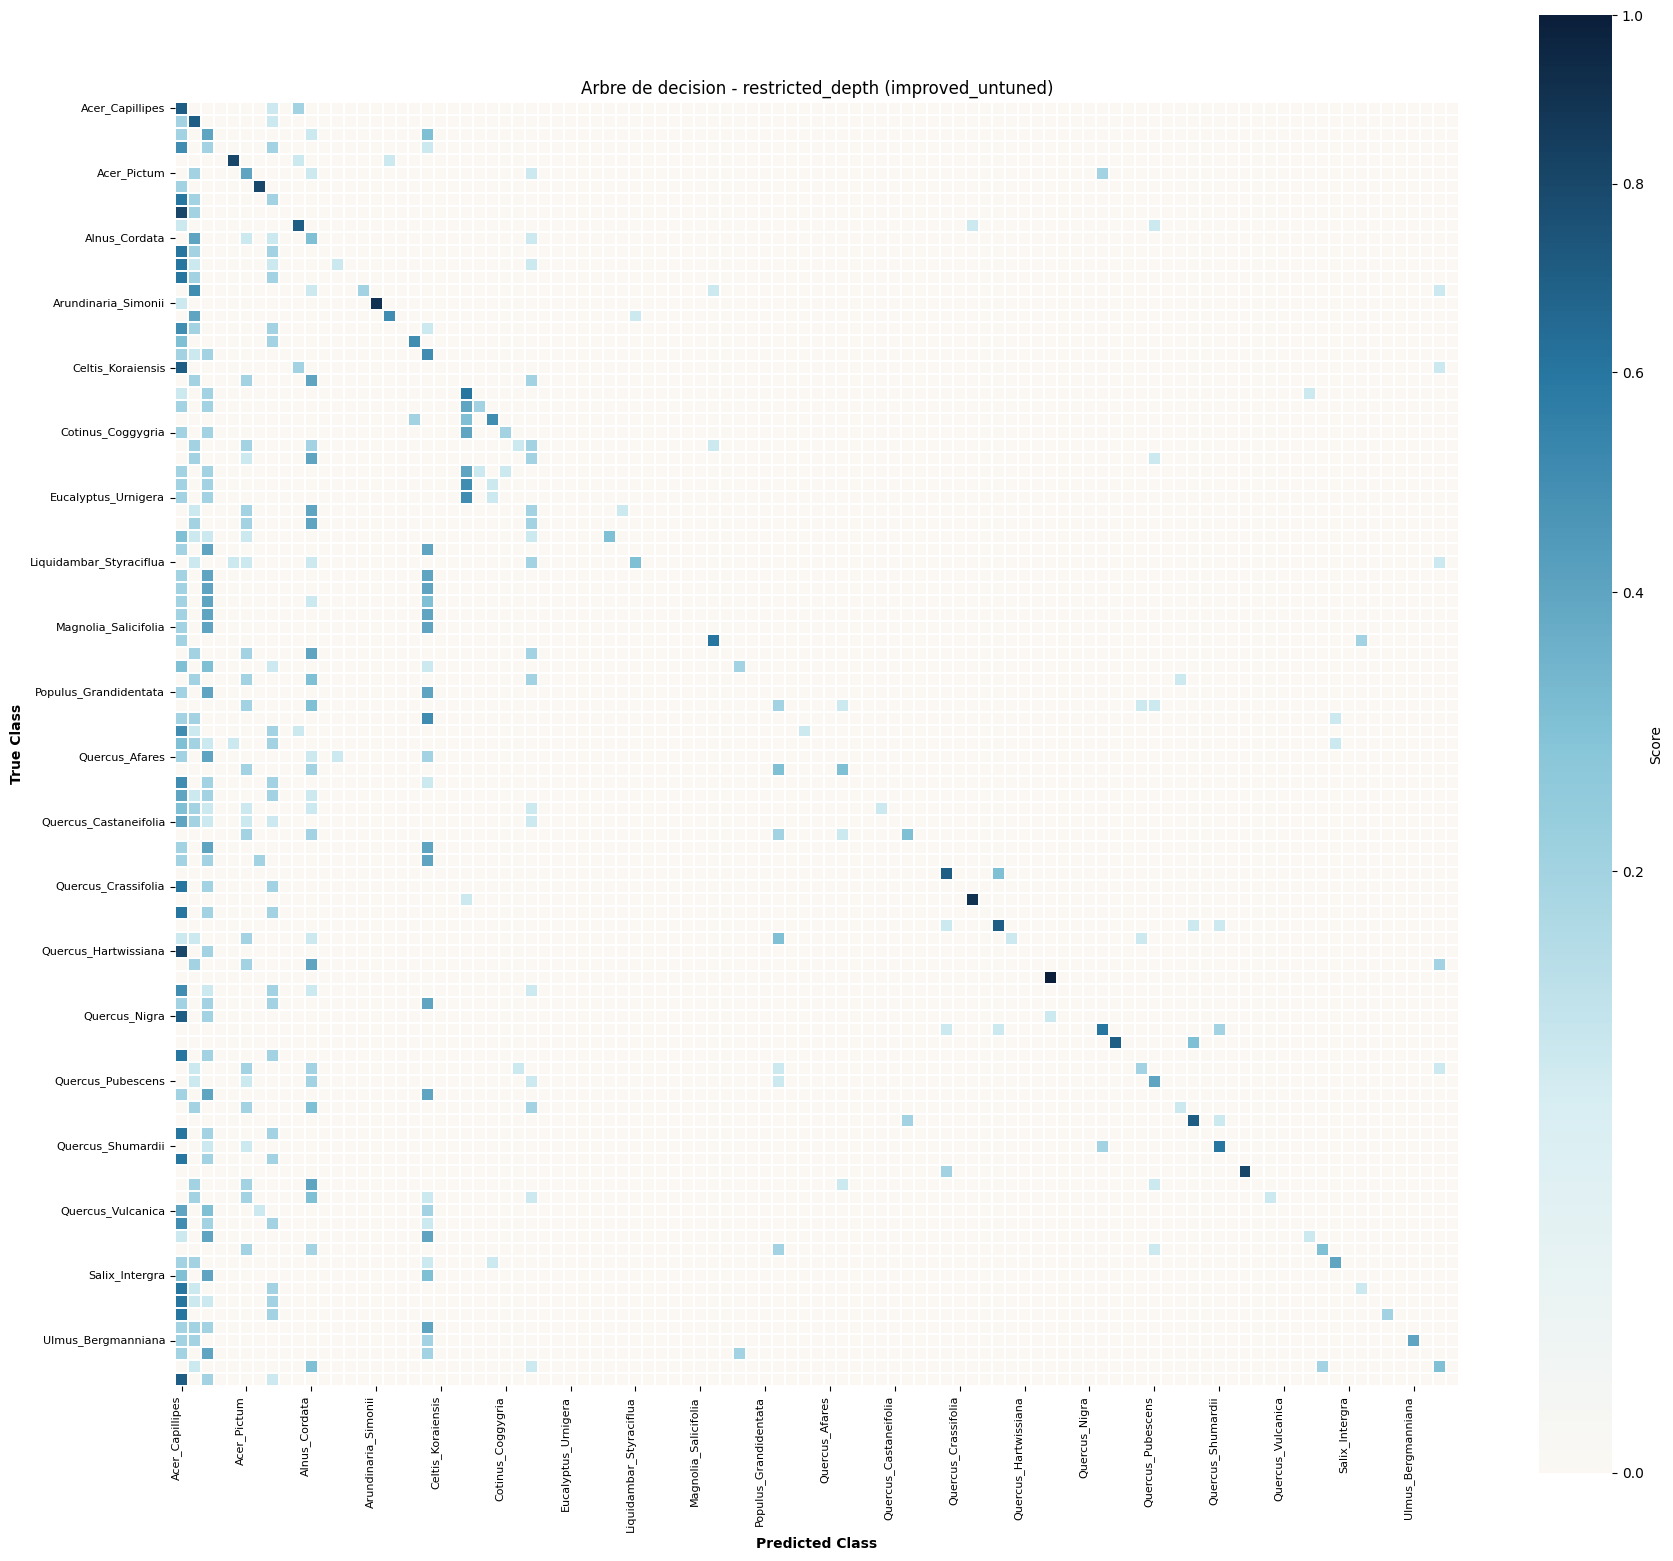

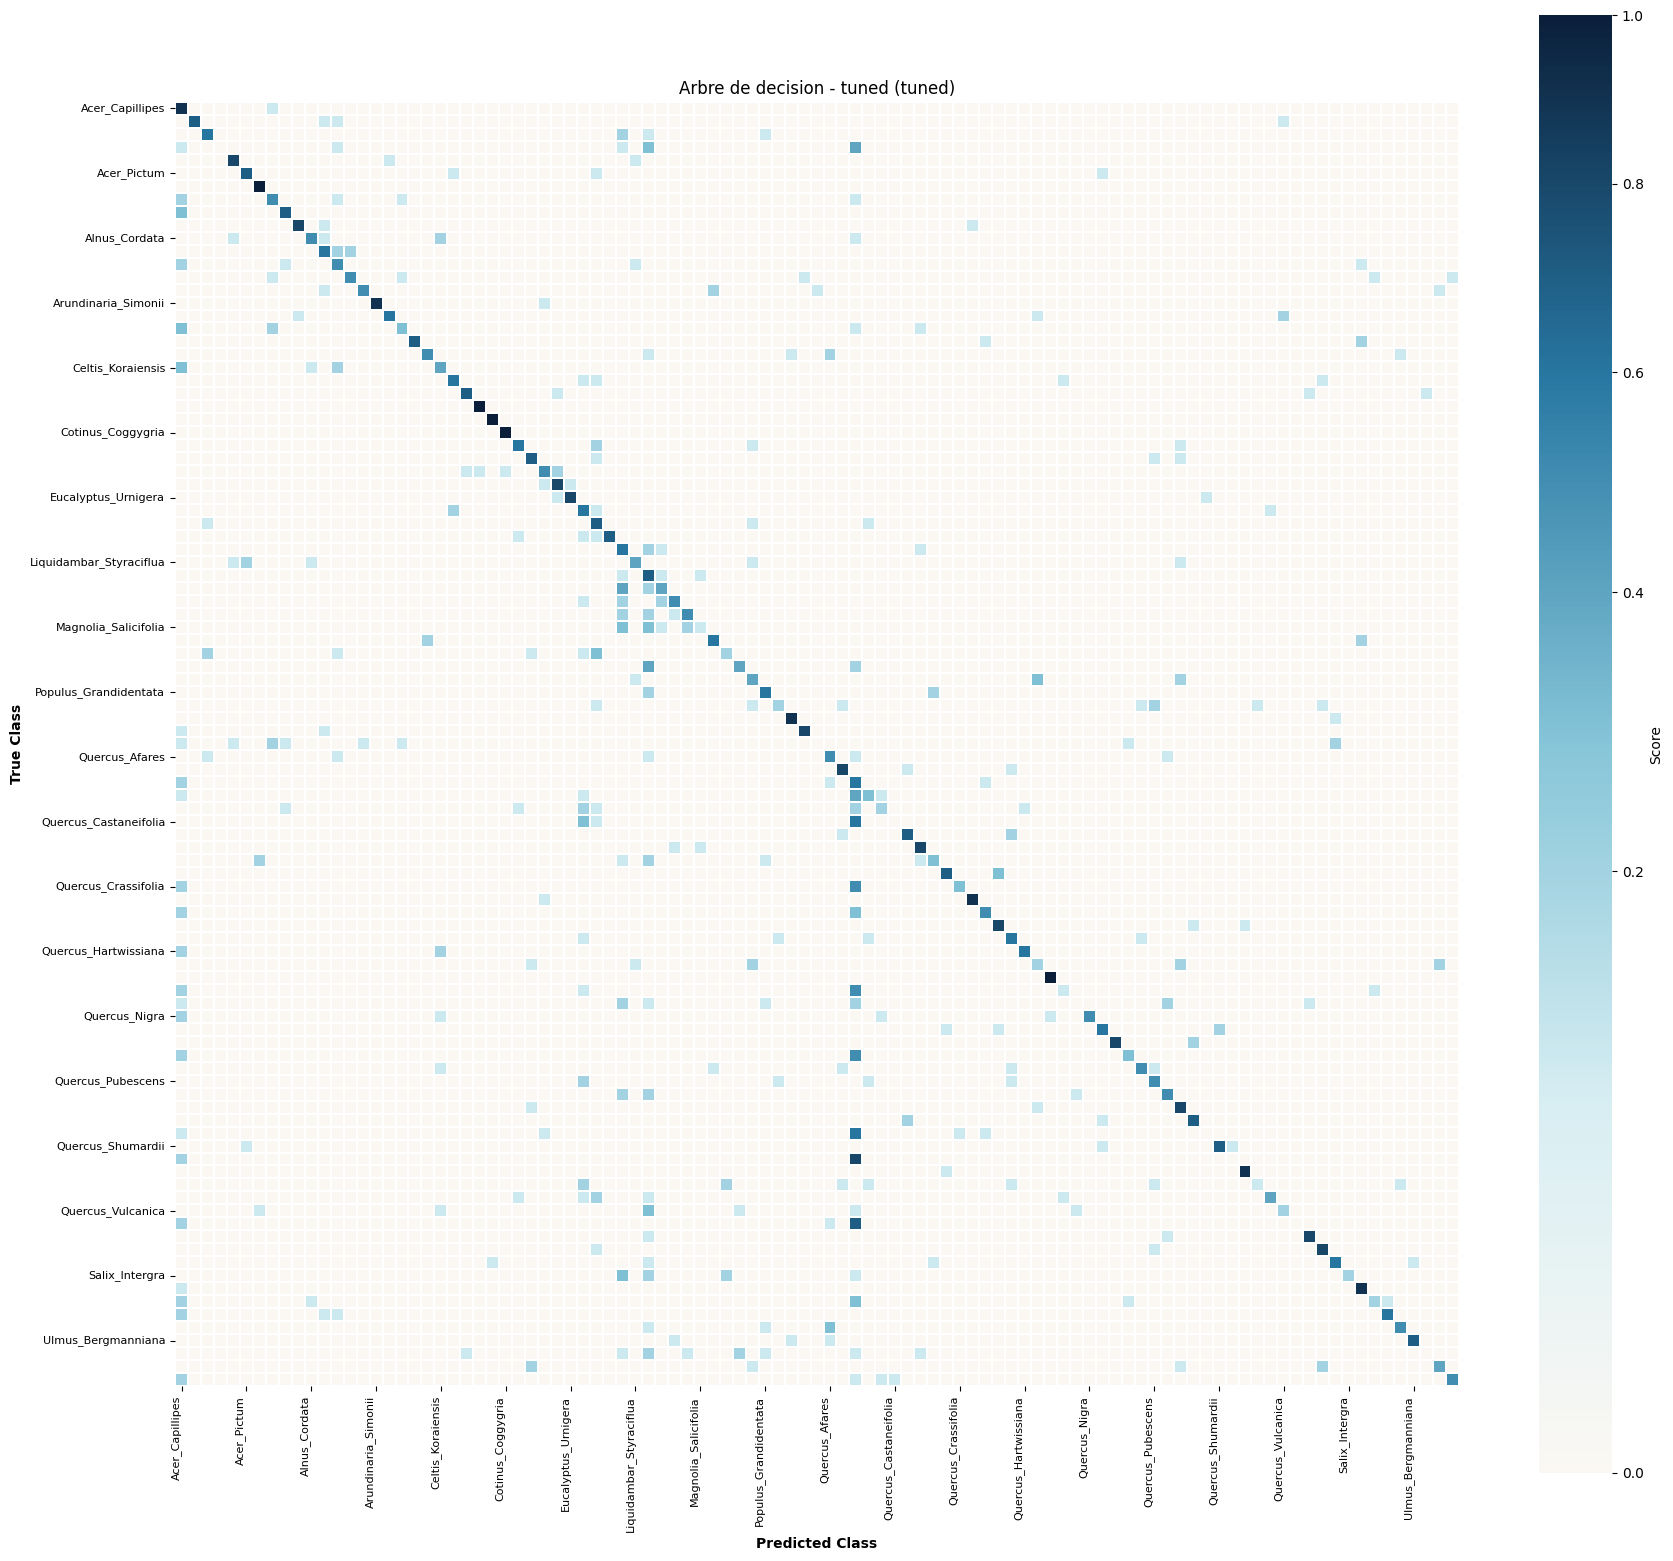

In [8]:
resume_confusions = construire_resume_confusions_variantes(
    MODEL_NAME,
    summary_table,
    X,
    y,
    label_encoder,
)
display(
    resume_confusions[[
        "variante",
        "evaluation_stage",
        "val_f1_macro_mean",
        "val_accuracy_mean",
        "generalization_gap_f1_macro",
        "confusion_dominante",
        "nombre_erreurs_dominantes",
    ]].round(4)
)

ordre_variantes = {
    "default": 0,
    "scaled_only": 1,
    "scaled_pca": 2,
    "restricted_depth": 3,
    "tuned": 99,
}

catalogue_variantes = (
    resume_confusions
    .assign(
        variante=lambda df: df["variante"].astype("string"),
        _ordre=lambda df: df["variante"].map(lambda v: ordre_variantes.get(str(v), 50)),
    )
    .sort_values(["_ordre", "variante"])
    .reset_index(drop=True)
)

for ligne in catalogue_variantes.to_dict("records"):
    variante = str(ligne["variante"])
    predictions_variante = charger_ou_generer_predictions_variante(
        MODEL_NAME,
        variante,
        X,
        y,
        label_encoder=label_encoder,
    )
    matrice = matrice_confusion_normalisee(
        predictions_variante["y_true"].to_numpy(),
        predictions_variante["y_pred"].to_numpy(),
        label_encoder=label_encoder,
    )
    tracer_matrice_confusion(
        matrice,
        titre=f"{definition['nom_affiche']} - {variante} ({ligne['evaluation_stage']})",
        annot=False,
        intervalle_ticks=5,
    )
    plt.show()


_Diagnostic exploratoire specifique._ Les importances ci-dessous proviennent d'un refit global
du meilleur estimateur exploratoire. Elles servent a illustrer des tendances descriptives et ne
doivent pas etre interpretees causalement.


In [9]:
importance = calculer_importance_permutation_exploratoire(
    tuning["grid"].best_estimator_,
    X,
    y,
    n_repeats=5,
)
display(importance.head(20).round(4))


,feature,importance_mean,importance_std
0,shape48,0.2876,0.0100
1,shape62,0.1389,0.0035
2,margin59,0.0995,0.0025
3,shape17,0.0764,0.0052
4,margin39,0.0705,0.0069
5,texture61,0.0600,0.0012
6,margin55,0.0482,0.0041
7,shape1,0.0464,0.0058
8,margin32,0.0451,0.0030
9,margin31,0.0450,0.0018


### Compromis profondeur / performance — diagnostic exploratoire

Validation curve montrant le score train et validation en fonction de `max_depth`.
Ce diagnostic illustre le compromis biais-variance specifique a l'arbre de decision.

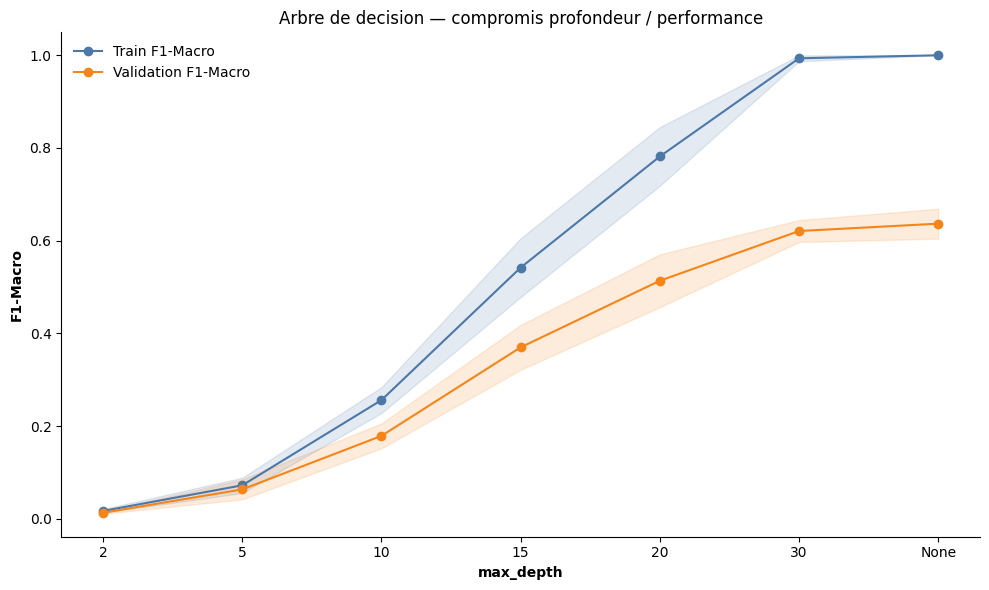

,max_depth,train_mean,train_std,val_mean,val_std
0,2,0.0172,0.0041,0.0132,0.0022
1,5,0.0724,0.0164,0.0635,0.0215
2,10,0.2561,0.0279,0.1790,0.0268
3,15,0.5420,0.0634,0.3700,0.0484
4,20,0.7817,0.0633,0.5136,0.0570
5,30,0.9934,0.0062,0.6209,0.0236
6,None,1.0000,0.0000,0.6368,0.0322


In [10]:
from src.models.pipelines import creer_estimateur

depth_data = validation_curve_max_depth(
    creer_estimateur("arbre_decision"),
    X, y,
)
tracer_validation_curve_max_depth(
    depth_data,
    titre=f"{definition['nom_affiche']} — compromis profondeur / performance",
)
plt.show()
display(depth_data.round(4))

## 7. Interpretation

Le texte ci-dessous reste automatiquement borne par les chiffres obtenus dans ce notebook.
Il ne doit pas servir a sur-interpreter des signaux purement exploratoires.


In [11]:
best_untuned = untuned_table.sort_values("val_f1_macro_mean", ascending=False).iloc[0]
tuned_row = summary_table.loc[summary_table["variante"] == "tuned"].iloc[0]
default_row = untuned_table.loc[untuned_table["variante"] == "default"].iloc[0]
lignes = [
    f"- Meilleure variante non tunee: `{best_untuned['variante']}` avec F1-macro = `{best_untuned['val_f1_macro_mean']:.4f}`.",
    f"- Estimation confirmatoire `tuned` en nested CV: F1-macro = `{tuned_row['val_f1_macro_mean']:.4f}` et accuracy = `{tuned_row['val_accuracy_mean']:.4f}`.",
]

if "scaled_only" in untuned_table["variante"].values:
    scaled_row = untuned_table.loc[untuned_table["variante"] == "scaled_only"].iloc[0]
    delta_scaling = scaled_row["val_f1_macro_mean"] - default_row["val_f1_macro_mean"]
    lignes.append(
        f"- Effet du scaling sur l'exploration: delta F1-macro = `{delta_scaling:+.4f}` entre `default` et `scaled_only`."
    )

delta_tuning = tuned_row["val_f1_macro_mean"] - best_untuned["val_f1_macro_mean"]
if abs(delta_tuning) < 0.005:
    lignes.append(
        "- Le tuning ne change pas materiellement la lecture scientifique par rapport a la meilleure variante exploratoire."
    )
elif delta_tuning > 0:
    lignes.append(
        f"- Le tuning confirme un gain de `{delta_tuning:+.4f}` en F1-macro par rapport a la meilleure variante exploratoire."
    )
else:
    lignes.append(
        f"- La nested CV donne une estimation plus conservative que l'exploration simple CV (delta F1-macro = `{delta_tuning:+.4f}`)."
    )

display(Markdown("\n".join(lignes)))


- Meilleure variante non tunee: `default` avec F1-macro = `0.6368`.
- Estimation confirmatoire `tuned` en nested CV: F1-macro = `0.5072` et accuracy = `0.5384`.
- La nested CV donne une estimation plus conservative que l'exploration simple CV (delta F1-macro = `-0.1296`).